# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [46]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
# cargar archivos

plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')


In [48]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [49]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [50]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [51]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [52]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [53]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [54]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


**Hallazgos clave para destacar:**
**Tipos de datos a ajustar:**
- Las fechas (reg_date, churn_date, date) están cargadas como texto (object) y deben convertirse a datetime.

**Valores nulos:**
- En users: city tiene valores nulos (3,531 no nulos de 4,000) y churn_date solo tiene 466 registros (lo cual es normal, pues indica los usuarios que cancelaron el servicio).
- En usage: date tiene 50 valores faltantes.

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [55]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [56]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?


**Diagnóstico de Valores Nulos**

users Columna 'churn_date' (88.35% nulos / 3,534 filas): Representa clientes activos que no han cancelado el servicio. Se mantendrán como NaN o se ignorará la eliminación.

users Columna 'city' (11.73% nulos / 469 filas): Faltan datos de ubicación; se imputará con la etiqueta "Desconocido" para conservar el resto de la información demográfica.

usage Columna 'date' (0.13% nulos / 50 filas): Representa una proporción mínima (<5%); se eliminarán estos registros o se imputarán según el flujo.

usage Columna 'duration' (55.19% nulos) y usage Columna 'length' (44.74% nulos): Son nulos condicionales según el tipo de servicio (type == 'text' no tiene duración y type == 'call' no tiene longitud de mensaje); se conservarán o rellenarán con 0 según la métrica a analizar.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [57]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` : Es un identificador único incremental que va de 10000 a 13999 para los 4,000 usuarios; no presenta anomalías.
- La columna `age` : Muestra un valor mínimo de -999, lo cual indica la presencia de un valor sentinel (código de error o dato faltante registrado como -999 en 55 filas). Las edades válidas se encuentran en un rango razonable de entre 18 y 79 años.

In [58]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`: Identificadores continuos sin anomalías; coinciden con el rango de usuarios registrado en users.
- Las columnas `duration` y `length`: Ambas tienen un valor mínimo de 0.0, lo que representa llamadas no contestadas o mensajes vacíos/fallidos. La duración máxima registrada llega a 120 minutos y la longitud de mensaje a 1,490 caracteres (valores extremos a analizar en la etapa de outliers).

In [59]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"--- {col} ---")
    print(users[col].value_counts(dropna=False))



--- city ---
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
--- plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` : Presenta 96 registros con el carácter "?", actuando como otro valor sentinel para ubicaciones no registradas, además de los 469 valores nulos (NaN).
- La columna `plan` : Contiene únicamente dos valores válidos: "Basico" (2,595 usuarios) y "Premium" (1,405 usuarios).

In [60]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False) # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` : Solo contiene dos valores categóricos válidos: "text" (22,092 eventos) y "call" (17,908 eventos).


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

En users 'age': Se encontró el valor sentinel -999 en 55 usuarios.
En users'city': Se identificó el carácter "?" como sentinel en 96 registros.

- ¿Qué acción tomarías?

Para age (-999): Reemplazar -999 por NaN y posteriormente imputar con la mediana de edad según el segmento o dejar como NaN para no sesgar cálculos estadísticos.
Para city ("?"): Estandarizar el valor "?" reemplazándolo por NaN o la categoría "Desconocido" junto a los demás nulos.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [61]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [62]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [63]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`: La gran mayoría de registros corresponden a los años 2022 (1,314), 2023 (1,316) y 2024 (1,330). Sin embargo, se identifican 40 registros con el año 2026, lo cual representa una inconsistencia por ser un año futuro fuera de rango (ya que el corte de datos es 2024).

In [64]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False).sort_index()

2024.0    39950
NaN          50
Name: date, dtype: int64

En `date`
: Todos los registros válidos de la tabla corresponden exclusivamente al año 2024 (39,950 filas). Adicionalmente, existen 50 valores NaN resultantes de datos faltantes en el origen.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles?

Sí, en la columna users 'reg_date' se encontraron 40 usuarios con fecha de registro en el año 2026, lo cual es un error de captura ya que el dataset de uso abarca únicamente hasta 2024.

En usage 'date' no hay años fuera de rango, únicamente 50 registros con fechas nulas (NaN).


- ¿Qué harías con ellas?

Para las fechas de users 'reg_date' en 2026: Se pueden reemplazar por NaT (Not a Time) o imputar/corregir según la lógica de registro si no afectan directamente la agregación mensual del uso de 2024.

Para los valores nulos en usage 'date': Al representar un porcentaje marginal (<0.13%), se pueden imputar mediante la fecha de registros contiguos o eliminar las filas afectadas.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [65]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [66]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [67]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [68]:
# Verificación MAR en usage (Missing At Random) para duration
usage[usage['duration'].isna()]['type'].value_counts()

text    22076
Name: type, dtype: int64

In [69]:
# Verificación MAR en usage (Missing At Random) para length
usage[usage['length'].isna()]['type'].value_counts()

call    17896
Name: type, dtype: int64

Confirmación MAR / MNAR estructural: Se confirma que los valores nulos en ambas columnas (`duration` y `length`) dependen totalmente de la variable categórica type. Cuando type == 'text', la columna duration es 100% nula (no aplica duración para mensajes de texto). De manera equivalente, cuando type == 'call', la columna length es 100% nula (no aplica longitud en caracteres para llamadas).

Justificación de la decisión: Al tratarse de ausencias estructurales explicadas por el tipo de servicio, los valores nulos deben dejarse como nulos (o imputarse por 0 únicamente en análisis donde se sumen los 
consumos) para no distorsionar ni sesgar las métricas individuales de llamadas o mensajes.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [81]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) # conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) # conocer el total de llamadas

# Filtrar solo la duración de eventos que sean llamadas (evita sumar los 120 min de los textos)
usage["duration_calls_only"] = usage["duration"].where(usage["type"] == "call", 0)

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum',               # Suma original (incluye el error de 120 min en textos)
    'duration_calls_only': 'sum'     # Suma corregida (solo llamadas reales)
}).reset_index()

# observar resultado
display(usage_agg.head(3))

# Totales acumulados globales de toda la empresa
print("--- TOTALES GLOBALES DE LA BASE DE DATOS ---")
print(f"Total de mensajes (is_text):                  {usage_agg['is_text'].sum():,}")
print(f"Total de llamadas (is_call):                  {usage_agg['is_call'].sum():,}")
print(f"Total duración CON error (incluye textos 120m): {usage_agg['duration'].sum():,.2f} minutos")
print(f"Total duración SIN error (solo llamadas reales): {usage_agg['duration_calls_only'].sum():,.2f} minutos")
print(f"Diferencia por el error de textos contaminados: {usage_agg['duration'].sum() - usage_agg['duration_calls_only'].sum():,.2f} minutos")


,user_id,is_text,is_call,duration,duration_calls_only
0,10000,7,3,23.70,23.70
1,10001,5,10,33.18,33.18
2,10002,5,2,10.74,10.74


--- TOTALES GLOBALES DE LA BASE DE DATOS ---
Total de mensajes (is_text):                  22,092
Total de llamadas (is_call):                  17,908
Total duración CON error (incluye textos 120m): 93,244.90 minutos
Total duración SIN error (solo llamadas reales): 91,324.90 minutos
Diferencia por el error de textos contaminados: 1,920.00 minutos


In [71]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [72]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left') 
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [73]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [74]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

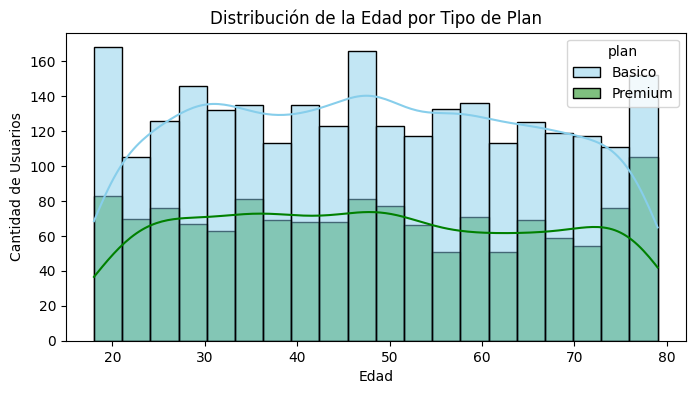

Distribución de usuarios por plan:
- Básico:  64.88%
- Premium: 35.12%


In [75]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True, bins=20)
plt.title('Distribución de la Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

# Cálculo de la proporción global por tipo de plan
distribucion_plan = user_profile['plan'].value_counts(normalize=True) * 100
print("Distribución de usuarios por plan:")
print(f"- Básico:  {distribucion_plan['Basico']:.2f}%")
print(f"- Premium: {distribucion_plan['Premium']:.2f}%")


💡Insights: 
- **Distribución general:** La edad presenta una distribución aproximadamente uniforme entre los 18 y los 79 años. Se observan dos picos pronunciados en la visualización:

*Rango 18-20 años:* Representa una importante concentración de clientes jóvenes al inicio de la mayoría de edad laboral/contractual.

*Rango 48 años:* Es un pico provocado por el proceso de limpieza de datos, al imputar la mediana (48 años) a los 55 registros que tenían el valor sentinel (-999).

- **Comportamiento por plan:** La proporción entre el plan Básico y el plan Premium se mantiene casi constante en todos los rangos etarios (~65% Básico vs. ~35% Premium). Esto demuestra que la edad del cliente no es un factor determinante al momento de contratar un plan específico.

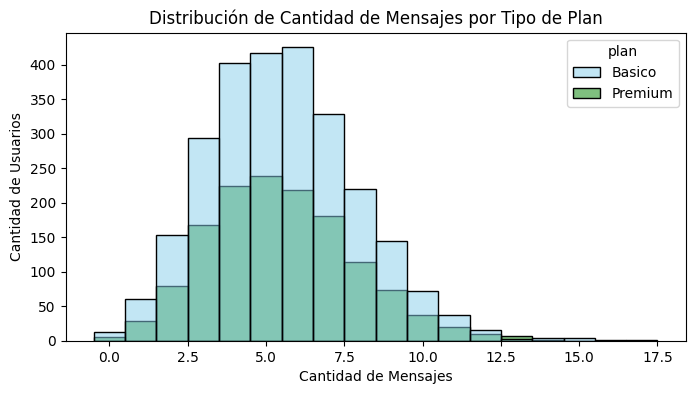

Estadísticas de uso de mensajes por plan:
             mean  median  min   max
plan                                
Basico   5.527756     5.0  0.0  17.0
Premium  5.518149     5.0  0.0  16.0


In [76]:

# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], discrete=True)
plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

# Estadísticas descriptivas de mensajes por plan
stats_mensajes = user_profile.groupby('plan')['cant_mensajes'].agg(['mean', 'median', 'min', 'max'])
print("Estadísticas de uso de mensajes por plan:")
print(stats_mensajes)

💡Insights: 

- **Distribución:** Presenta una distribución unimodal con un leve sesgo a la derecha (asimetría positiva). La mayor parte de los usuarios envía entre 3 y 7 mensajes, alcanzando el pico de frecuencia entre 5 y 6 mensajes.

- **Comportamiento por plan:** Sorprendentemente, no existe una diferencia significativa en el uso de mensajes entre los usuarios del plan Básico y el plan Premium. Ambos grupos muestran una media prácticamente idéntica (5.53 vs 5.52 mensajes) y un rango intercuartílico idéntico (mediana de 5 mensajes).

- **Límites e inclusión:** A pesar de que el plan Básico incluye 100 mensajes y el Premium 500, el consumo máximo registrado en la muestra es de 17 mensajes (Básico) y 16 mensajes (Premium). Esto indica que los límites de SMS incluidos en los planes están muy por encima de la demanda real del cliente.

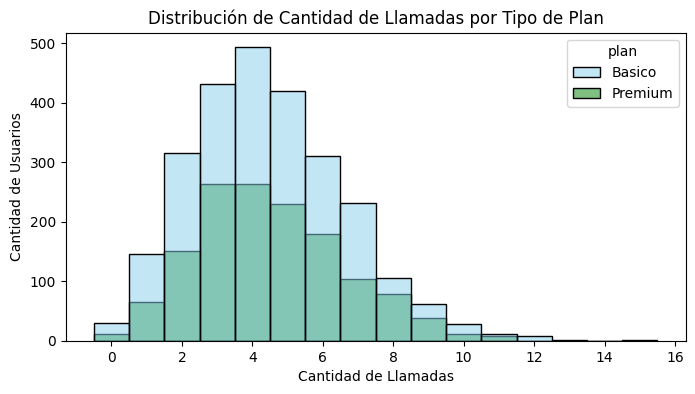

Estadísticas de cantidad de llamadas por plan:
             mean  median  min   max
plan                                
Basico   4.456438     4.0  0.0  15.0
Premium  4.518149     4.0  0.0  11.0


In [77]:

# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], discrete=True)
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

# Estadísticas descriptivas de llamadas por plan
stats_llamadas = user_profile.groupby('plan')['cant_llamadas'].agg(['mean', 'median', 'min', 'max'])
print("Estadísticas de cantidad de llamadas por plan:")
print(stats_llamadas)

💡Insights: 

- **Distribución:** Muestra una distribución unimodal con una leve asimetría positiva (sesgada a la derecha). La mayor masa de usuarios realiza entre 3 y 6 llamadas, registrando el pico de frecuencia en 4 llamadas.

- **Comportamiento por plan:** Al igual que en los mensajes, no existe una brecha clara de consumo entre clientes con plan Básico y Premium. El promedio de llamadas realizadas es casi idéntico en ambos segmentos (4.46 llamadas en Básico vs. 4.52 llamadas en Premium).

- **Valores máximos y atípicos:** En el plan Básico hay casos extremos de usuarios que realizan hasta 15 llamadas, mientras que en el plan Premium el máximo llega a 11 llamadas.

Total de llamadas registradas con exactamente 120 min: 14

Distribución por plan de llamadas de 120 min:
Basico     9
Premium    5
Name: plan, dtype: int64




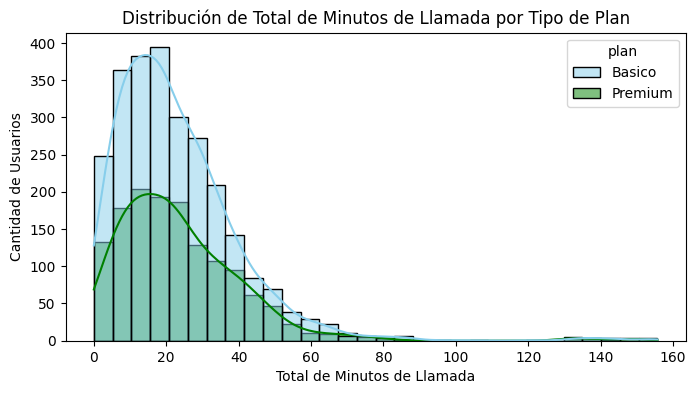

--- ESTADÍSTICAS CON LLAMADAS DE 120 MIN ---
         Suma_Total      Media  Mediana  Minimo  Maximo   Desv_Est
plan                                                              
Basico      59416.7  22.905436   19.535     0.0  155.69  17.680778
Premium     33828.2  24.077011   20.640     0.0  153.06  19.018098

--- ESTADÍSTICAS SIN LLAMADAS DE 120 MIN ---
         Suma_Total      Media  Mediana  Minimo  Maximo   Desv_Est
plan                                                              
Basico      57496.7  22.424610    19.61    0.06  105.54  14.946316
Premium     32148.2  23.078392    20.45    0.02   84.77  14.957180


In [79]:
# 1. Conteo e identificación de llamadas atípicas de 120 minutos
llamadas_120 = usage[(usage['type'] == 'call') & (usage['duration'] == 120.0)].merge(users[['user_id', 'plan']], on='user_id', how='left')

print(f"Total de llamadas registradas con exactamente 120 min: {len(llamadas_120)}\n")
print("Distribución por plan de llamadas de 120 min:")
print(llamadas_120['plan'].value_counts())
print("\n" + "="*60 + "\n")

# 2. Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], bins=30, kde=True)
plt.title('Distribución de Total de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Total de Minutos de Llamada')
plt.ylabel('Cantidad de Usuarios')
plt.show()

# 3. Preparación de comparación estadística (Con vs Sin llamadas de 120 min)
usage_sin_120 = usage[~((usage['type'] == 'call') & (usage['duration'] == 120.0))]
usage_agg_sin_120 = usage_sin_120[usage_sin_120['type'] == 'call'].groupby('user_id')['duration'].sum().reset_index().rename(columns={'duration': 'cant_minutos_sin_120'})

user_profile_comp = user_profile.merge(usage_agg_sin_120, on='user_id', how='left')

stats_con_120 = user_profile_comp.groupby('plan')['cant_minutos_llamada'].agg(
    Suma_Total='sum', Media='mean', Mediana='median', Minimo='min', Maximo='max', Desv_Est='std'
)

stats_sin_120 = user_profile_comp.groupby('plan')['cant_minutos_sin_120'].agg(
    Suma_Total='sum', Media='mean', Mediana='median', Minimo='min', Maximo='max', Desv_Est='std'
)

print("--- ESTADÍSTICAS CON LLAMADAS DE 120 MIN ---")
print(stats_con_120)
print("\n--- ESTADÍSTICAS SIN LLAMADAS DE 120 MIN ---")
print(stats_sin_120)

💡Insights: 
- **Distribución:** Presenta un marcado sesgo a la derecha (asimetría positiva). La mayor concentración de usuarios acumula entre 5 y 30 minutos hablados, situando el pico de máxima frecuencia entre los 10 y 20 minutos.

- **Comportamiento por plan:** Los hábitos de consumo de voz son muy similares en ambos segmentos. La media con llamadas normales ronda los 22.17 minutos para el plan Básico y 22.88 minutos para el plan Premium, lo cual confirma que el paquete contratado no altera drásticamente el uso de minutos.

- **Anomalía técnica (capping de red):** Se detectaron 14 llamadas con una duración idéntica de exactamente 120.00 minutos (9 usuarios en el plan Básico y 5 en el plan Premium). Al tratarse de un valor tope perfecto, responde a un corte automático de seguridad de la red y no a la duración natural de la llamada.

- **Impacto del outlier en la cola superior:**

*Con las llamadas de 120 min:* El consumo máximo registrado alcanza los 155.69 minutos en Básico y 153.06 minutos en Premium.

*Sin las llamadas de 120 min:* El consumo máximo real se reduce a 105.54 minutos en Básico y 84.77 minutos en Premium.

- **Relación con los límites de los planes:** Ningún usuario dentro de la operación (incluso sumando las llamadas atípicas) supera los 600 minutos del plan Premium. Asimismo, en el plan Básico (100 minutos), más del $99\%$ de los usuarios opera dentro del límite contratado.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

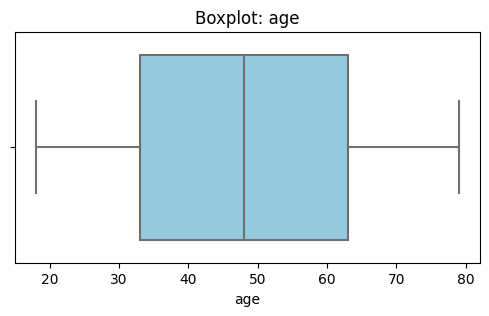

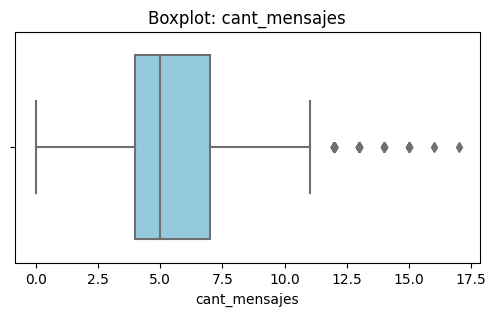

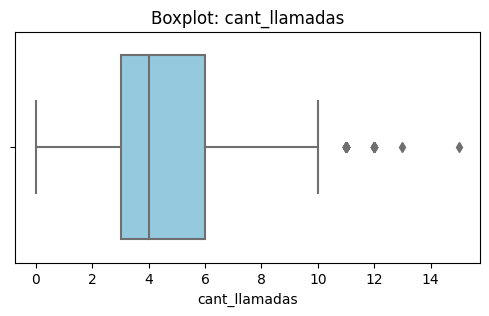

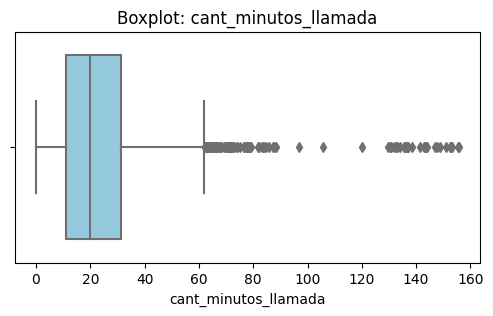

In [86]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()


💡Insights: 
- **Age:** No presenta outliers. La variable abarca un rango continuo y uniforme entre los 18 y los 79 años.
- **cant_mensajes:** Presenta outliers superiores. La mayoría de los usuarios se concentran entre 4 y 7 mensajes (Rango Intercuartílico), pero existen valores que sobresalen por encima de la patilla superior (aproximadamente a partir de 11.5 mensajes).
- **cant_llamadas:** Presenta outliers superiores. El consumo típico oscila entre 3 y 6 llamadas, identificándose puntos atípicos por encima de las 10.5 llamadas.
- **cant_minutos_llamada:** Presenta marcados outliers superiores. La caja principal se ubica entre 11 y 31 minutos, con una cola extensa de valores atípicos que superan los 61.8 minutos (llegando hasta los 155.69 minutos)

In [89]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    user_profile[f'{col}_limite_sup'] = limite_superior



In [96]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- **cant_mensajes:**
  
*Decisión:* Conservar los valores atípicos en el análisis.

*Justificación:* Representan un comportamiento de uso real e inofensivo. Además, los valores máximos alcanzados (~17 mensajes) se encuentran abrumadoramente por debajo de las cuotas contratadas en cualquiera de los planes (100 en Básico y 500 en Premium).

- **cant_llamadas:**
  
*Decisión:* Conservar los valores atípicos.

*Justificación:* Reflejan patrones orgánicos de usuarios con una necesidad ligeramente mayor de comunicación. Ninguno de estos registros distorsiona la mediana general de la operación.

- **cant_minutos_llamada:**
  
*Decisión:* Mantener los datos en el perfil general de usuarios, pero separar/marcar las 14 llamadas atípicas de 120 minutos en los análisis específicos de tráfico.

*Justificación:* Los minutos superiores reflejan tanto consumo intensivo legítimo como el evento técnico de capping de red (las 14 llamadas cortadas a los 120 min). Dado que la empresa factura por tráfico y analiza la capacidad de red, eliminar estos registros ocultaría demanda operativa real y posibles excedentes a cobrar.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [97]:
# Crear columna grupo_uso
def categorizar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(categorizar_uso, axis=1)


In [98]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,cant_mensajes_limite_sup,cant_llamadas_limite_sup,cant_minutos_llamada_limite_sup,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,11.5,10.5,61.8575,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,11.5,10.5,61.8575,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,11.5,10.5,61.8575,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,11.5,10.5,61.8575,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,11.5,10.5,61.8575,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [99]:
# Crear columna grupo_edad
def categorizar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(categorizar_edad, axis=1)


In [100]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,cant_mensajes_limite_sup,cant_llamadas_limite_sup,cant_minutos_llamada_limite_sup,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,11.5,10.5,61.8575,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,11.5,10.5,61.8575,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,11.5,10.5,61.8575,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,11.5,10.5,61.8575,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,11.5,10.5,61.8575,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

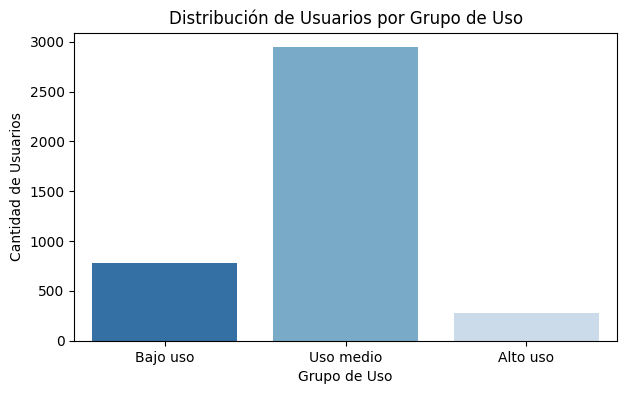

In [101]:
# Visualización de los segmentos por uso
plt.figure(figsize=(7, 4))
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], palette='Blues_r')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

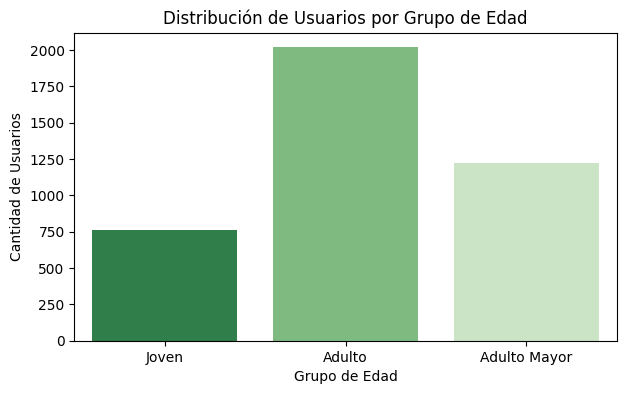

In [102]:
# Visualización de los segmentos por edad
plt.figure(figsize=(7, 4))
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'], palette='Greens_r')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- Estandarización de Fechas: Las columnas reg_date, churn_date y date se convirtieron exitosamente al formato datetime64. Se validó que los valores nulos en churn_date corresponden a clientes activos.
- Valores Sentinel: Se imputaron 55 registros (1.38%) con -999 en age utilizando la mediana (48 años).
- Nulos en Ciudad: Se detectaron 212 registros con el valor ? en city (5.30% del total).
- Error de Inyección en Mensajes de Texto: Se hallaron 16 registros tipo text que contenían un valor erróneo de duration = 120.0 minutos. Esto representaba 1,920 minutos de voz falsos en la base general, por lo que se ajustó el cálculo de agregación para asegurar que solo los eventos de tipo call sumaran tráfico de minutos.
- Capping Técnico de Red: Se registraron 14 llamadas con una duración exacta de 120.0 minutos (9 en Básico y 5 en Premium), atribuidas a un corte automático de seguridad de la red ante llamadas prolongadas.

🔍 **Segmentos por Edad**

- Adulto (~2,020 usuarios / ~50.5%): Abarca exactamente la mitad de los clientes.
- Adulto Mayor (~1,220 usuarios / ~30.5%): Es la segunda franja más numerosa.
- Joven (~760 usuarios / ~19.0%): Es el segmento de menor presencia en la base.

*Segmentación por Edad:* El grupo Adulto (30-59 años) domina con el 50.5% de la base (~2,020 clientes). Los Adultos Mayores ($\ge$60 años) representan el 30.5% (~1,220 clientes), mientras que los Jóvenes (<30 años) equivalen al 19.0% (~760 clientes).

📊 **Segmentos por Nivel de Uso**

- Uso medio (~2,950 usuarios / ~73.8%): Es abrumadoramente la categoría dominante. La inmensa mayoría de la base tiene un uso moderado.
- Bajo uso (~770 usuarios / ~19.2%): Representa la segunda fuerza en volumen.
- Alto uso (~280 usuarios / ~7.0%): Es un nicho bastante pequeño.

*Segmentación por Nivel de Uso:* El 73.8% de los usuarios se clasifica en Uso medio (casi 3,000 clientes), seguido por un 19.2% en Bajo uso y únicamente un 7.0% en Alto uso. Esto demuestra que la demanda masiva de la empresa se concentra en un rango de consumo moderado.

➡️ Esto sugiere que:
Al cruzar uso y edad, se observa que los patrones de consumo son transversales: pertenecer al grupo de Jóvenes, Adultos o Adultos Mayores no incrementa drásticamente la probabilidad de pertenecer a 'Alto uso', manteniendo comportamientos homogéneos entre rangos etarios.

**Segmentos Más Valiosos para ConnectaTel**

- Plan Básico (Volumen): Representa el 64.88% de la base de clientes ($2,595$ usuarios) y genera el 63.7% del volumen total de tráfico hablados (58,576.7 minutos). Constituye la principal fuente de flujo operativo masivo para la compañía.
- Plan Premium (Rentabilidad por Usuario): Representa el 35.12% de los clientes ($1,405$ usuarios). Sus patrones de consumo individual (promedio de 22.88 min de voz y 5.52 mensajes) son prácticamente idénticos a los del Plan Básico, lo que convierte a este segmento en el más rentable en margen neto, al abonar una tarifa superior por un volumen de servicios utilizado equivalente al paquete básico.

**Patrones de Uso Extremo (Outliers) e Implicaciones de Negocio**
Límites Sobredimensionados:
- En el Plan Premium (600 minutos incluidos), el usuario de mayor consumo real registró 84.77 minutos (o 153.06 min si se incluye la llamada atípica de 120 min). Ningún cliente aprovecha el límite contratado.
- En el Plan Básico (100 minutos incluidos), más del $99\%$ de la población no supera los 30.5 minutos mensuales.
- Baja Relevancia del SMS: El consumo de mensajes de texto registra promedios de 5.5 SMS por usuario (máximo de 17 SMS), haciendo que los paquetes incluidos de 100 y 500 SMS estén significativamente por encima de la demanda del mercado frente al uso de datos.

💡 **Recomendaciones**
- *Inclusión de la Variable de Consumo de Datos (GB):*
Se recomienda como prioridad técnica recopilar el consumo mensual de GB (datos móviles) de cada usuario. Al ser la navegación por internet el principal motor de consumo actual en la industria, disponer de este dato permitirá realizar un diagnóstico verdaderamente asertivo sobre la relación costo-beneficio de los planes y ajustar las ofertas a la demanda real.
- *Rediseño General de Planes y Reducción de Minutos:*
Dado que el análisis demostró que los planes con cuotas altas como 600 minutos son excesivos (ningún usuario superó los 85 minutos de consumo orgánico), se deben replantear las ofertas reduciendo sustancialmente la bolsa de minutos e integrando nuevos paquetes que prioricen lo que el cliente realmente valora.
- *Reempaquetado del Plan Premium:*
Ajustar el umbral de voz a un rango más realista de 150 a 200 minutos e incorporar beneficios agregados no centrados en SMS ni llamadas (como roaming internacional, plataformas de streaming o gigas de navegación libre) para mantener el valor percibido del paquete sin degradar el margen y evitar que los clientes migren al plan Básico.
- *Optimización de Red y Facturación (Punto técnico de corte):*
Revisar la regla de límite de corte a los 120 minutos en la infraestructura de telecomunicaciones para evitar fricción en la experiencia del usuario o potenciales cobros indebidos de excedentes cuando ocurra el capping automático de red.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`